<a href="https://colab.research.google.com/github/bahenaeduardo170-pixel/README.md/blob/main/notebooks/connectatel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")#completa el código
usage = pd.read_csv("/datasets/usage.csv")#completa el código

In [ ]:
print("-----PLANS-----")
print(plans.head())# mostrar las primeras 5 filas de plans

-----PLANS-----
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [ ]:
print("\n----- USERS -----")
print(users.head())# mostrar las primeras 5 filas de users


----- USERS -----
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [ ]:
print("\n----- USAGE -----")
print(usage.head())# mostrar las primeras 5 filas de usage


----- USAGE -----
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("\n----- INFO PLANS -----")
plans.info()# inspección de plans con .info()


----- INFO PLANS -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("\n----- INFO USERS -----")
users.info()# inspección de users con .info()


----- INFO USERS -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("\n----- INFO USAGE -----")
usage.info()# inspección de usage con .info()


----- INFO USAGE -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users
print("----- USERS -----")
print("Cantidad de nulos:")# Cantidad de valores nulos)
print(users.isna().sum())
print("\nProporción de nulos:")
print(users.isna().mean())# Proporción de valores nulos)


----- USERS -----
Cantidad de nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print("\n----- USAGE -----")

print("Cantidad de nulos:")
print(usage.isna().sum())


print("\nProporción de nulos:")
print(usage.isna().mean())


----- USAGE -----
Cantidad de nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.


---city:
Presenta 11.7% de valores nulos.
Acción: imputar como "unknown", ya que es una variable categórica importante para segmentación y el porcentaje es moderado.

churn_date:
Presenta 88.3% de valores nulos.
Acción: no imputar, ya que los valores nulos representan clientes activos. Esta variable contiene información de negocio relevante (churn vs no churn).


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
print("----- USERS NUMERIC -----")
print(users.describe()) # explorar columnas numéricas de users

----- USERS NUMERIC -----
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000



- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna user_id representa un identificador único por usuario.
Sus valores son consistentes, secuenciales y no presentan anomalías.
Acción: no requiere limpieza ni tratamiento.
-La columna age presenta un valor mínimo de -999, lo cual es un valor inválido (sentinel).
Además, la desviación estándar es muy alta (123), lo que confirma la presencia de valores extremos que distorsionan la distribución.
Acción: reemplazar -999 por NaN para posteriormente imputar o tratar correctamente estos valores.


In [ ]:
print("----- USERS NUMERIC -----")
print(users.describe()) # explorar columnas numéricas de usage

----- USERS NUMERIC -----
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


Las columnas id y user_id son identificadores, por lo que no aportan valor analítico directo.




In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print(users[col].value_counts(dropna=False))





--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


La columna city presenta dos problemas:
1. Valores nulos (~11.7%)
2. Presencia del valor "?" que representa un sentinel (dato inválido)

Acción:
- Reemplazar "?" por "unknown"
- Mantener NaN o imputar como "unknown" para análisis posterior
La columna plan contiene únicamente valores válidos ("Basico" y "Premium") sin inconsistencias.
Acción: no requiere limpieza.

In [ ]:


# explorar columna categórica de usage
print("\n--- usage type ---")
print(usage['type'].value_counts()) # completa el código




--- usage type ---
text    22092
call    17908
Name: type, dtype: int64


La columna type contiene dos valores válidos: "text" y "call".
No presenta inconsistencias ni valores inválidos.
Acción: no requiere limpieza.


---


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?age: se detectó el valor -999, el cual representa un dato inválido. Este valor afecta la media, desviación estándar y distribución de la edad. city: se identificó la presencia del valor "?", el cual representa un dato desconocido o mal capturado.
- No se detectaron valores inválidos en las demás columnas relevantes, ya que los valores nulos en duration y length son estructurales (dependen del tipo de evento: llamadas o mensajes).
- ¿Qué acción tomarías?  
Acción: reemplazar -999 por NaN para posteriormente imputar o tratar estos valores correctamente.
reemplazar "?" por "unknown" para estandarizar la categoría y facilitar el análisis.
No se detectaron valores inválidos en las demás columnas relevantes, ya que los valores nulos en duration y length son estructurales (dependen del tipo de evento: llamadas o mensajes).

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce")# completa el código

In [ ]:


# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce")# completa el código



In [ ]:
# Revisar los años presentes en `reg_date` de users
users["year"] = users["reg_date"].dt.year
print("Años en users:")
print(users["year"].value_counts().sort_index())

Años en users:
2022    1314
2023    1316
2024    1330
2026      40
Name: year, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
columna reg_date se identificaron años 2022, 2023 y 2024, los cuales son válidos y consistentes con el periodo de análisis.

Sin embargo, también se detectaron 40 registros con el año 2026, lo cual representa un error de captura ya que el análisis está limitado hasta 2024.

Acción: estos registros deben ser corregidos o eliminados, ya que corresponden a fechas futuras que pueden distorsionar el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage

usage["year"] = usage["date"].dt.year  # ← Esta línea falta
print("Años en users:")
print(users["year"].value_counts().sort_index())
print("\nAños en usage:")
print(usage["year"].value_counts().sort_index())

Años en users:
2022    1314
2023    1316
2024    1330
2026      40
Name: year, dtype: int64

Años en usage:
2024.0    39950
Name: year, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En la columna date se observa que todos los registros pertenecen al año 2024, lo cual es consistente con el periodo de análisis.

No se detectaron años fuera de rango ni valores atípicos en esta columna.

Acción: no se requiere limpieza adicional para esta variable.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Se identificaron fechas fuera de rango en la columna reg_date del dataset users.

Específicamente, se detectaron registros con el año 2026, lo cual es inconsistente ya que el análisis está limitado hasta el año 2024. Estas fechas representan errores de captura o registro.
 - En la columna date del dataset usage no se detectaron años fuera de rango, ya que todos los registros pertenecen al año 2024.
- ¿Qué harías con ellas?
- eliminar los registros con fechas mayores a 2024, ya que corresponden a valores futuros que pueden distorsionar el análisis temporal y las conclusiones del negocio.
-

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users["age"] !=-999, "age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT  # ✅ Correcto: NaT
# Verificar cambios
print(users["reg_date"].isna().sum())  # También corregir la sintaxis del print

40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duratio
print(usage.groupby("type")["duration"].apply(lambda x: x.isna().mean))

type
call    <bound method NDFrame._add_numeric_operations....
text    <bound method NDFrame._add_numeric_operations....
Name: duration, dtype: object


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
- Se observó que duration presenta valores nulos cuando el tipo de registro corresponde a mensajes de texto ("text"), ya que los mensajes no tienen duración de llamada.
- length presenta valores nulos casi exclusivamente cuando el tipo de registro corresponde a llamadas ("call"), ya que las llamadas no tienen longitud de mensaje.

Esto indica que los valores faltantes dependen directamente del tipo de evento registrado y corresponden al comportamiento esperado del negocio.

Por lo tanto, los nulos en estas columnas son MAR (Missing At Random) y no representan errores de captura.

Acción recomendada:
Mantener estos valores como nulos y no imputarlos, ya que reemplazarlos podría generar inconsistencias en el análisis.



---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",        # ✅ Correcto: con 'a' al final
    "cant_minutos_llamada"  # ✅ Correcto: con 'a' al final
]
print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True))

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

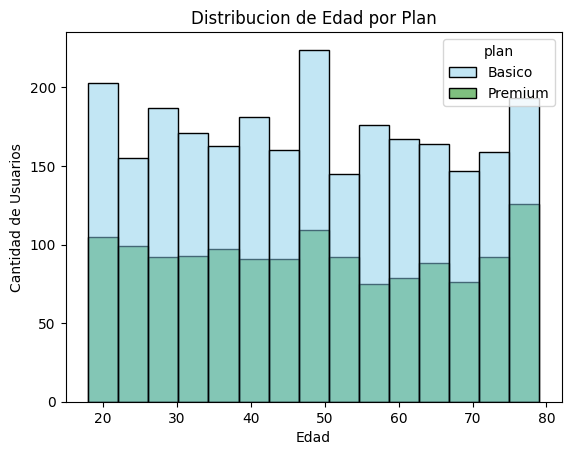

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
            x="age",
            hue="plan",
            palette=["skyblue", "green"],
            bins=15
            )
plt.title("Distribucion de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()

💡Insights:
-No se observan diferencias importantes de edad entre los usuarios Basico y Premium. Ambos planes presentan distribuciones similares a lo largo de los distintos rangos de edad.

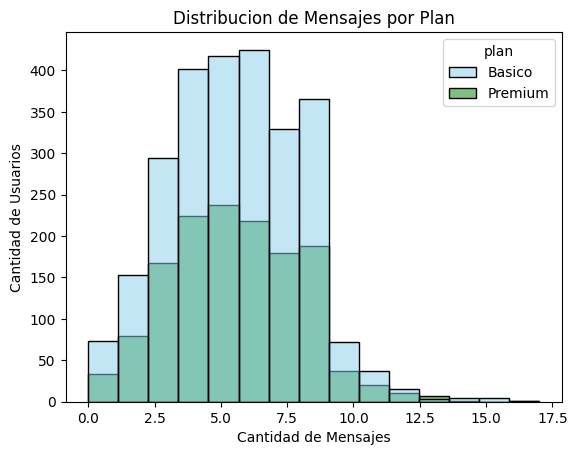

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=15
)
plt.title("Distribucion de Mensajes por Plan")
plt.xlabel("Cantidad de Mensajes")  # ✅ Sin indentación extra
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
-Los usuarios de ambos planes presentan comportamientos similares en el envío de mensajes. La mayoría concentra un volumen moderado de mensajes y no se observan diferencias fuertes entre Basico y Premium.

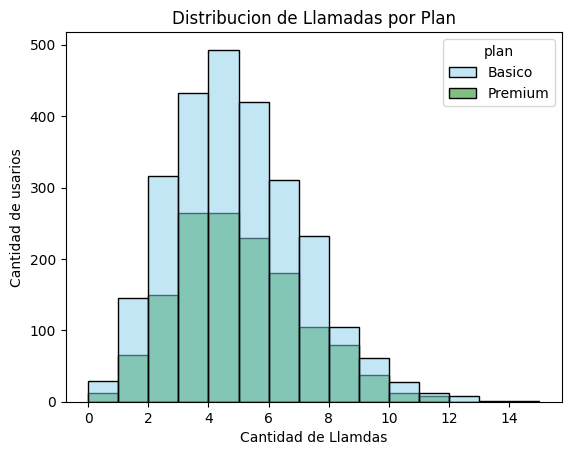

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=15
)
plt.title("Distribucion de Llamadas por Plan")
plt.xlabel("Cantidad de Llamdas")
plt.ylabel("Cantidad de usarios")

plt.show()

💡Insights:
- Distribución ligeramente sesgada a la derecha

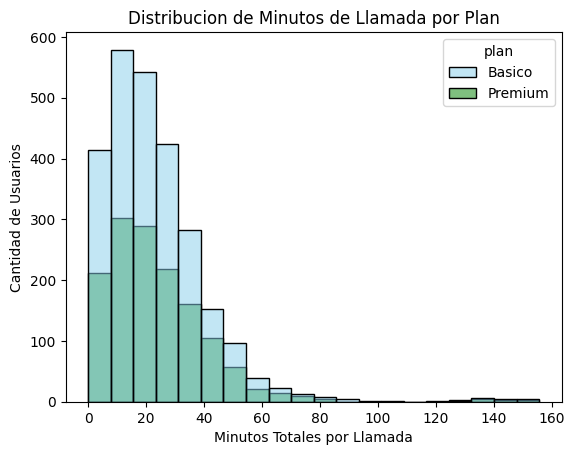

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribucion de Minutos de Llamada por Plan")
plt.xlabel("Minutos Totales por Llamada")
plt.ylabel("Cantidad de Usuarios")

plt.show()

💡Insights:
- La variable de minutos de llamada presenta una distribución fuertemente sesgada a la derecha. La mayoría de los usuarios consume pocos minutos, mientras que un pequeño grupo concentra consumos extremadamente altos.

Esto sugiere la presencia de usuarios intensivos o posibles outliers. Además, el plan Premium parece presentar una dispersión ligeramente mayor en el consumo de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

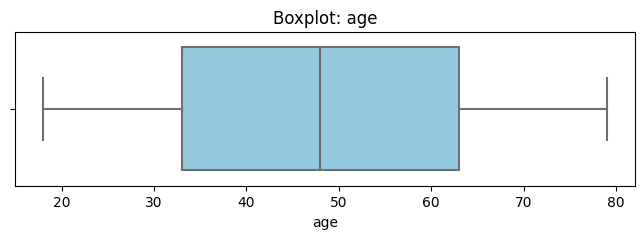

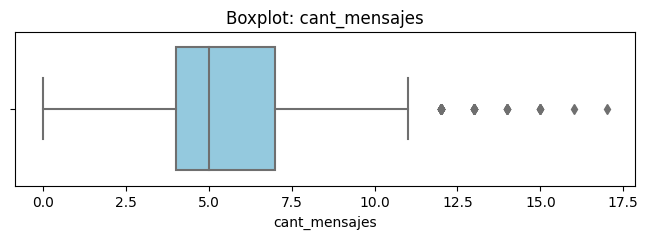

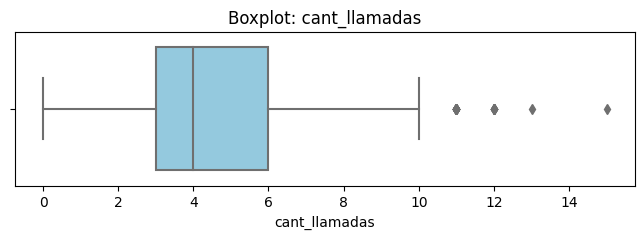

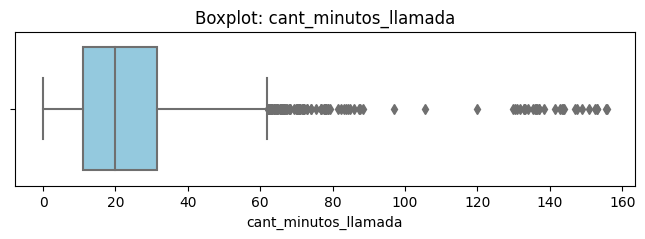

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,2))  # ✅ Indentado con 4 espacios
    sns.boxplot(                # ✅ Indentado con 4 espacios
        x=user_profile[col],
        color="skyblue"
    )
    plt.title(f"Boxplot: {col}")  # ✅ Indentado + corregir el f-string
    plt.show()

💡Insights:
- Age: no presenta outliers relevantes después de la limpieza de sentinels.
- cant_mensajes: presenta algunos valores altos, pero permanecen dentro de los límites esperados según el método IQR.
- cant_llamadas: presenta valores altos moderados, pero siguen dentro de los límites aceptables según el método IQR.
- cant_minutos_llamada: presenta una cantidad importante de outliers en el extremo superior, indicando usuarios con consumos extremadamente altos respecto al comportamiento típico.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n--- {col} ---")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Limite superior:", user_profile[col].max())





--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite superior: 17.0

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite superior: 15.0


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas
count,3999.000000,3999.000000
mean,5.524381,4.478120
std,2.358416,2.144238
min,0.000000,0.000000
25%,4.000000,3.000000
50%,5.000000,4.000000
75%,7.000000,6.000000
max,17.000000,15.000000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener,  se recomienda mantener los valores altos, ya que permanecen dentro de los límites esperados y representan comportamientos posibles de usuarios reales.
- cant_llamadas: mantener o no outliers, porqué? Mantener,  se recomienda mantener los valores altos debido a que permanecen dentro de los límites estadísticos y representan variaciones normales del comportamiento de los clientes.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener temporalmente, aunque existen outliers claros en el extremo superior, se recomienda mantenerlos temporalmente, ya que podrían representar usuarios intensivos reales y aportar información importante para el análisis de comportamiento y segmentación.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
import numpy as np

user_profile["grupo_uso"]=np.where(
    (user_profile["cant_llamadas"] <5 ) &
    (user_profile["cant_mensajes"] <5 ),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] <10) &
        (user_profile["cant_mensajes"] <10),
        "Uso medio",
        "Alto uso"
    )
)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    "Joven",
    np.where(
        user_profile["age"] < 60,
        "Adulto",           # ✅ Agregar coma aquí
        "Adulto Mayor"      # ✅ Correcto
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

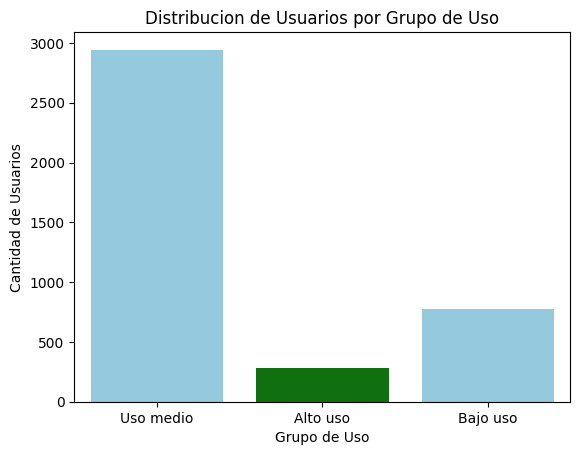

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,
             x="grupo_uso",
             palette=["skyblue", "green"]
             )
plt.title("Distribucion de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")

plt.show()

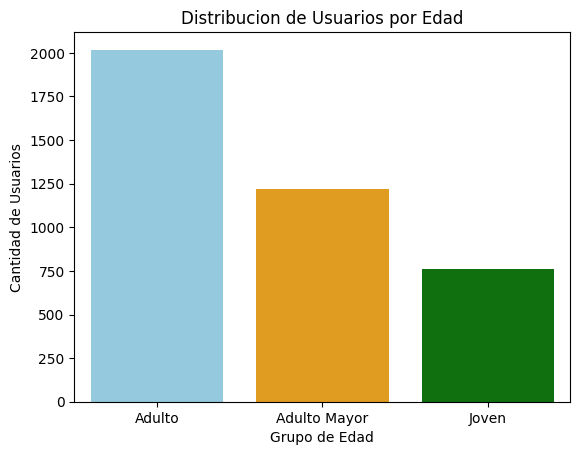

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue", "orange", "green"]
)
plt.title("Distribucion de Usuarios por Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron valores inválidos como edades negativas (-999), ciudades con “?” y fechas fuera de rango (2026). Estos valores fueron corregidos usando mediana, NA y validación de fechas. También se confirmó que los nulos en duration y length dependen del tipo de registro y no representan errores.


🔍 **Segmentos por Edad**
- La mayoría de los clientes pertenece al grupo Adulto, seguido por Adulto Mayor. Los usuarios Jóvenes representan la menor proporción de la base. Esto indica que ConnectaTel tiene mayor presencia en segmentos de edad media y adulta.


📊 **Segmentos por Nivel de Uso**
- El grupo dominante corresponde a usuarios de Uso medio, mientras que los usuarios de Alto uso representan una minoría. También se detectaron outliers en minutos de llamada, asociados a usuarios con consumos intensivos.


➡️ Esto sugiere que ...
La mayoría de los clientes presenta consumos moderados, pero existe un segmento pequeño de usuarios intensivos que podría representar clientes de alto valor para planes Premium y estrategias de retención.

💡 **Recomendaciones**
- Se recomienda crear planes específicos para usuarios intensivos, campañas para usuarios de bajo uso y estrategias segmentadas por edad. También es importante fortalecer las validaciones automáticas para mejorar la calidad de los datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`